In [2]:
# Configure path.
import sys; import os
sys.path.append(os.path.abspath('..'))

%matplotlib inline
import numpy as np
import importlib, pickle
import matplotlib.pyplot as plt
plt.style.use('dissertation.mplstyle')
from IPython.display import clear_output

from python import forces, integrators, random_matrix, simulate, densities, plotters, newton
importlib.reload(forces); importlib.reload(integrators); importlib.reload(random_matrix)
importlib.reload(simulate); importlib.reload(densities); importlib.reload(plotters); importlib.reload(newton);

---

Calculating the determinant of the matrix in the Metropolis-Hastings step (implicit),
$$
A = I_N + \Delta t \beta N \nabla^2 H_N(x),
$$
where
$$
\nabla^2 H_N(x) = \begin{cases}
            -\frac{1}{N(x_k - x_{\ell})^2}, \quad &k \neq \ell,\\
            \frac{1}{2}V''(x_k) + \frac{1}{N}\sum_{j \neq k}\frac{1}{(x_k - x_{\ell})^2}, \quad &k = \ell. 
        \end{cases}
$$

First we use the Cholesky factorisation: if using $A = LL^*$, then $\log \det(A)$ can be written
$$
\det(A) = \det(LL^*) = \det(L)^2 \implies \log \det(A) = 2\log\det(L) = 2\log \prod_{i=1}^N L_{ii} = 2\sum_{j = 1}^N \log(L_{ii}) . 
$$

In [3]:
# Build the matrix using Numba, compute the determinant using Cholesky (Scipy solver for now).
N = 500; dt = 0.1; beta = 2; potential = "quadratic"; 
potential_ints = {"quadratic": 0, "quad-quartic": 1, "quartic": 2}
M = 3; x_full = random_matrix.init_gue_eigenvalues(M, N)
pot_int = potential_ints[potential]

for j in range(M):
    x = x_full[j]; v_double_prime = forces.evaluate_force(x, pot_int, 2)
    log_det = newton.cholesky_log_det(x, beta, dt, v_double_prime)
    print(log_det)

4668.569473406803
4694.601949267814
4689.120841093462


---

See the new `maila_newton_step()` in integrators.py.

In [14]:
N = 50; dt = 0.05; T = 20; M = 200;
potential_name = "quartic"; beta = 2.0;
init = random_matrix.init_quartic_eigenvalues(M, N)
total_steps = int(T/dt)
config = {"track_accepts": True, "snapshot_interval": 1}

pipe = simulate.make_maila_pipeline(N, dt, potential_name, beta)
trajectory = simulate.simulate_dbm(init, total_steps, pipe)
info = simulate.analyse_trajectory(trajectory, total_steps, **config)

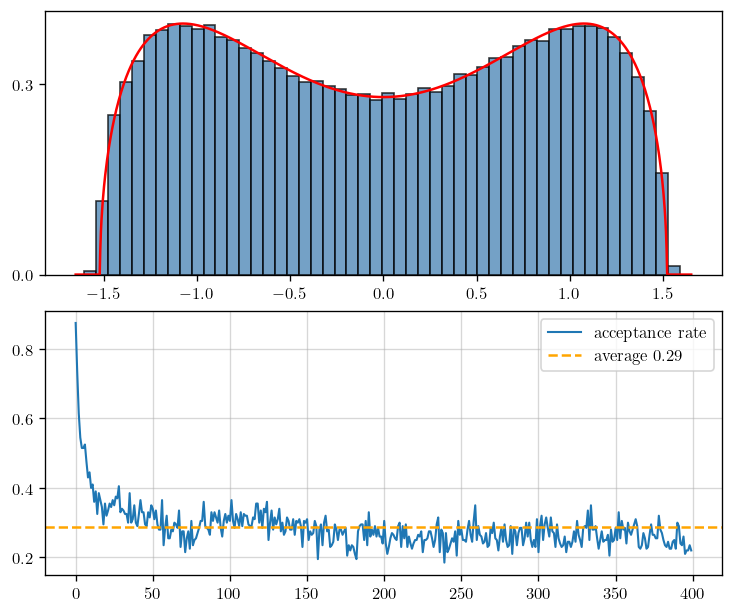

In [16]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (6, 5))
plotters.plot_hist(ax1, info["snapshots"], potential_name = potential_name, num_bins = 50)
plotters.plot_accepts(ax2, info["accepts"])

plt.show()